In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import json 
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter 
from scipy.signal import find_peaks
from Oscilloscope.Oscilloscope import Oscilloscope

**burada işimizi kolaylaştırmak Oscilloscope adında bir class oluşturdum**

In [2]:
osiloskop_info = Oscilloscope(['0.bin'])

In [3]:
#osiloskop_info.saveAsJson('berker/data.json')

In [4]:
readData = pd.DataFrame(osiloskop_info.channel[1].data)

In [5]:
readData[readData[0]>0.25]

,0
16,1.56
17,0.52
46,0.40
129,0.28
141,0.96
142,0.40
145,5.08
146,1.96
147,0.68
148,0.32


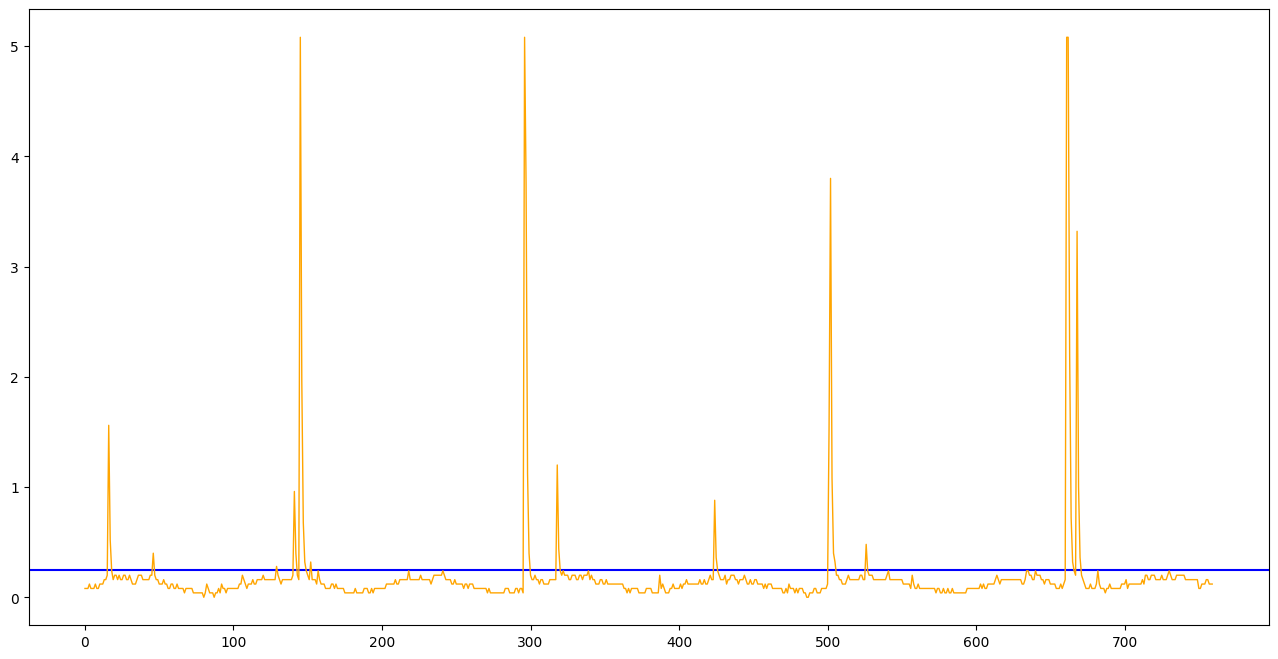

In [6]:
plt.figure(figsize=(16, 8))
plt.axhline(0.25, color = 'blue', linestyle = '-')
plt.plot(readData, color="orange", linewidth=1)

In [7]:
smootedData = readData[[0]].apply(savgol_filter,  window_length=4, polyorder=3)
smootedData2 = smootedData[[0]].apply(savgol_filter,  window_length=5, polyorder=3)

array([[<Axes: title={'center': '0'}>]], dtype=object)

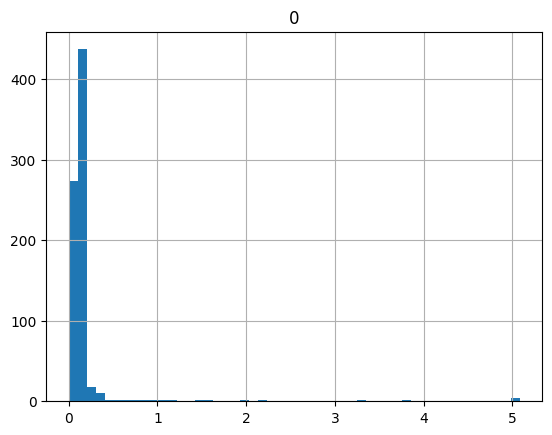

In [8]:
readData.hist(bins=50)

In [9]:
np.histogram(readData[[0]],bins = 50)

(array([273, 437,  18,  10,   2,   1,   1,   1,   1,   2,   1,   2,   0,
          0,   1,   1,   0,   0,   0,   1,   0,   1,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   1,   0,   0,   0,   0,   2,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   4]),
 array([0.    , 0.1016, 0.2032, 0.3048, 0.4064, 0.508 , 0.6096, 0.7112,
        0.8128, 0.9144, 1.016 , 1.1176, 1.2192, 1.3208, 1.4224, 1.524 ,
        1.6256, 1.7272, 1.8288, 1.9304, 2.032 , 2.1336, 2.2352, 2.3368,
        2.4384, 2.54  , 2.6416, 2.7432, 2.8448, 2.9464, 3.048 , 3.1496,
        3.2512, 3.3528, 3.4544, 3.556 , 3.6576, 3.7592, 3.8608, 3.9624,
        4.064 , 4.1656, 4.2672, 4.3688, 4.4704, 4.572 , 4.6736, 4.7752,
        4.8768, 4.9784, 5.08  ]))

In [10]:
sorted = readData.sort_values(0)
filtered = sorted[int(len(sorted)*0.2):int(len(sorted)*0.80)]
filtered

,0
581,0.08
675,0.08
678,0.08
751,0.08
750,0.08
...,...
439,0.16
442,0.16
326,0.16
347,0.16


In [11]:
std = np.std(filtered[0])
std

0.0318772460871054

In [12]:
avg = np.average(filtered[0])
avg

0.12473684210526316

In [13]:
trshld = avg + std*(2+2**0.5)
peaks, _ = find_peaks(smootedData[0],threshold = 0.04)
filtredPeaks = smootedData[0][peaks][smootedData[0]>0]
filtredPeaks = filtredPeaks.keys()

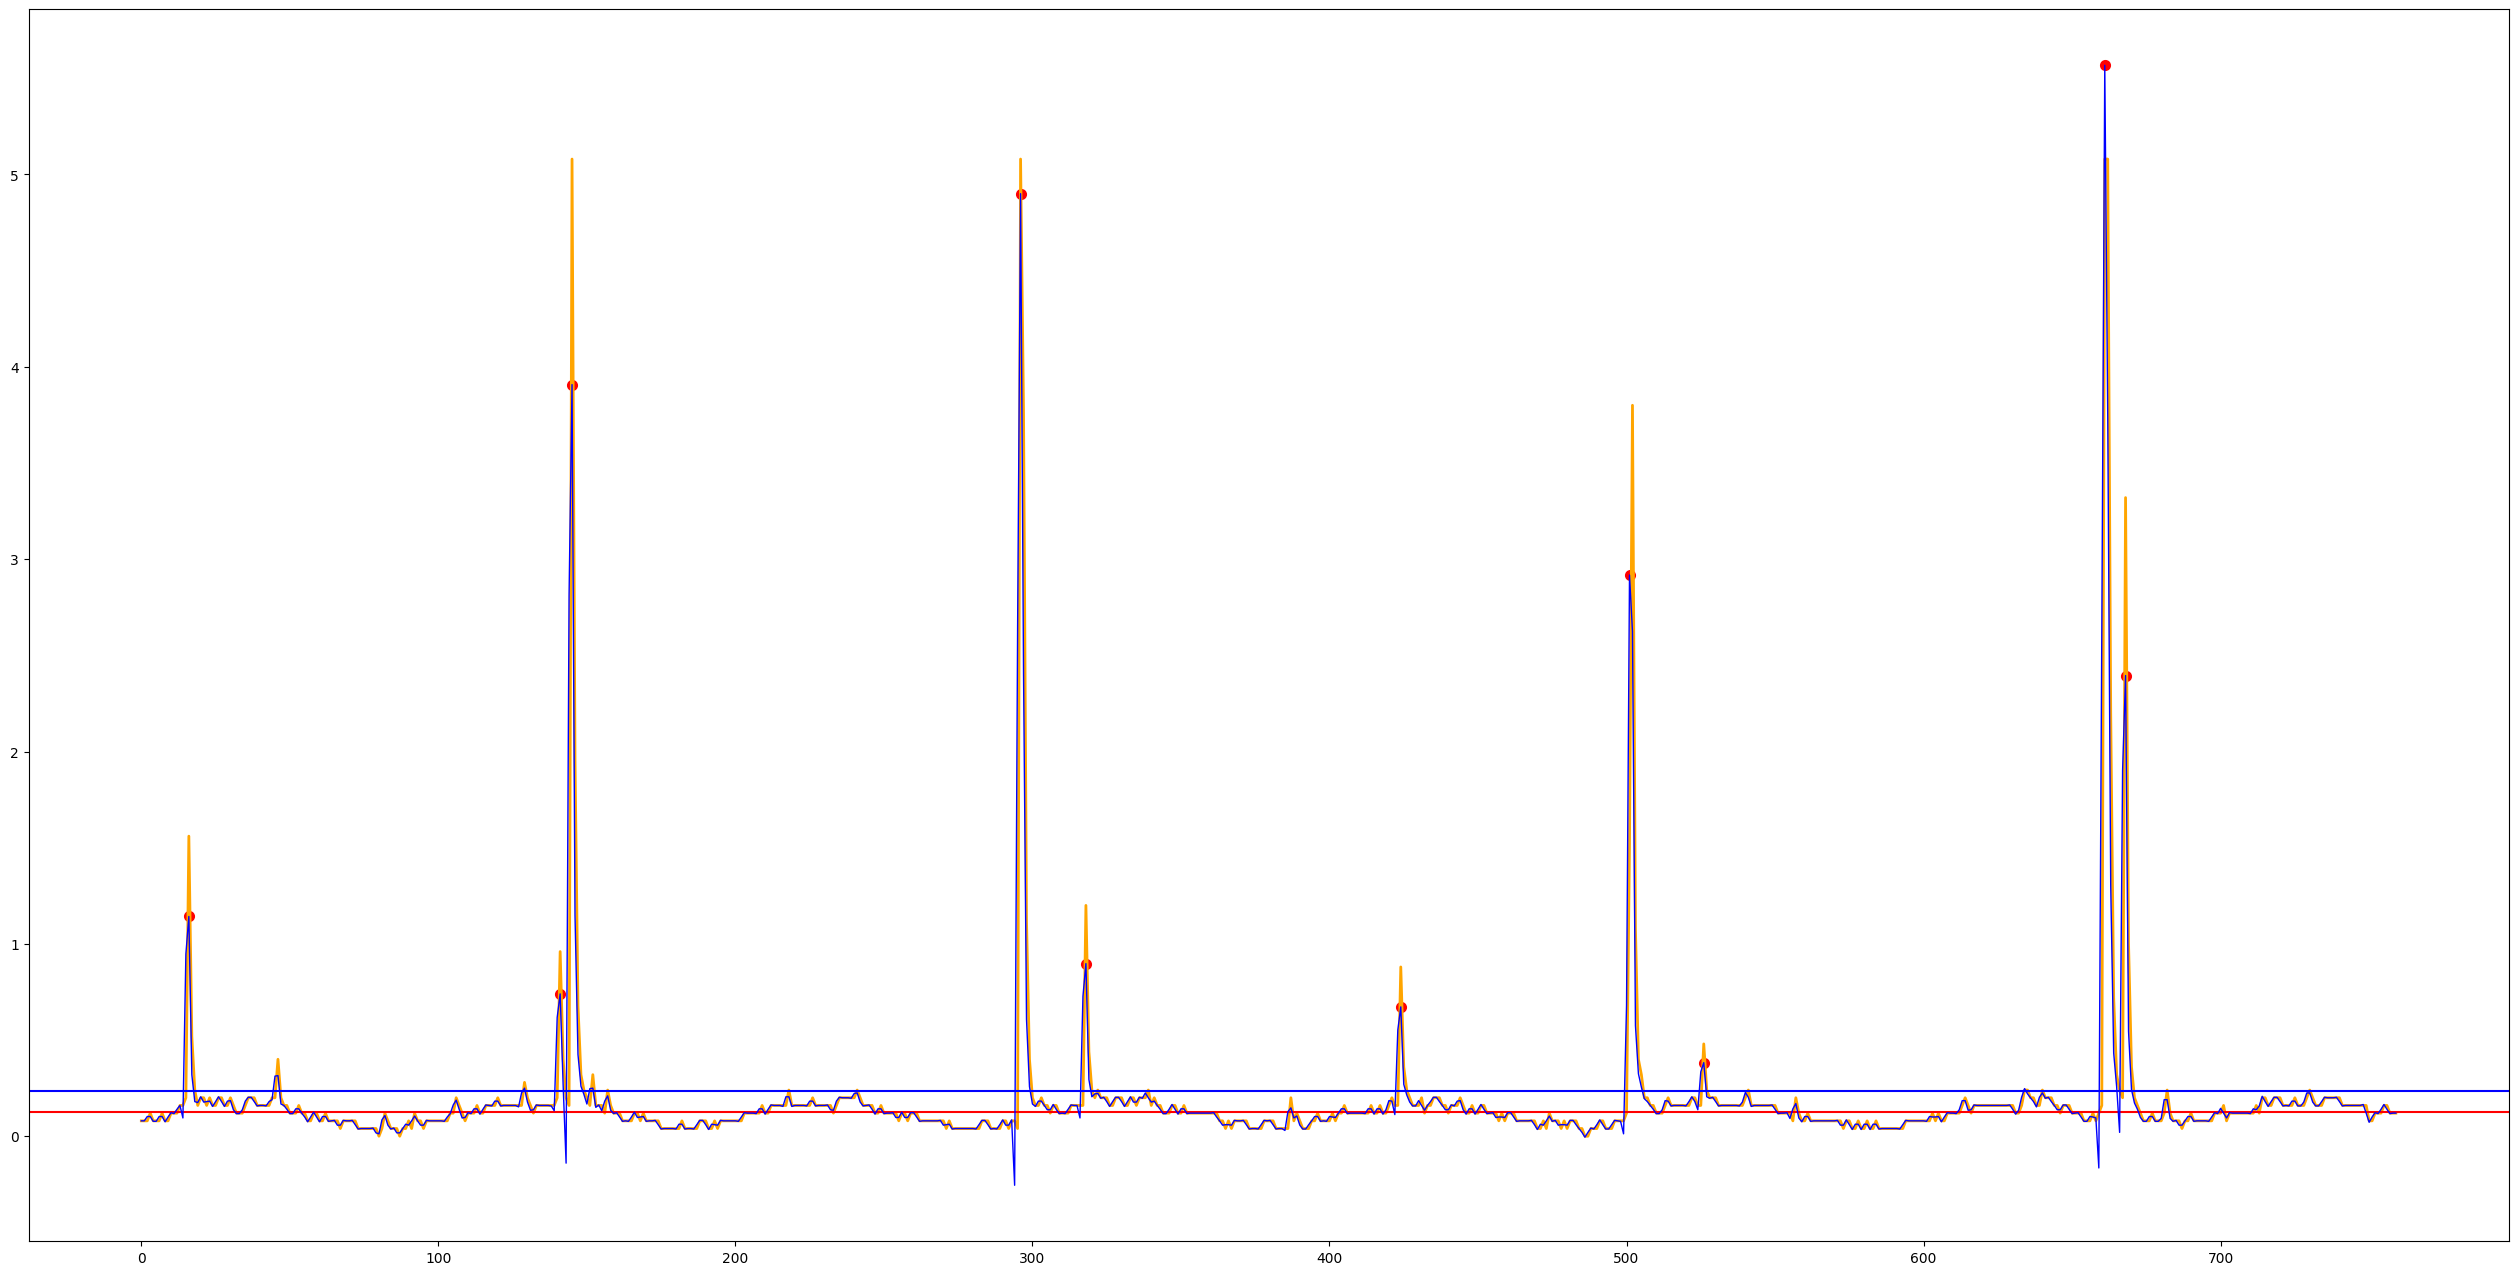

In [14]:

plt.figure(figsize=(32, 16))
plt.plot(range(0,len(readData)),readData, color="orange", linewidth=2)

plt.axhline(avg, color = 'r', linestyle = '-')
plt.axhline(trshld, color = 'blue', linestyle = '-')

plt.plot(range(0,len(smootedData)),smootedData, color="blue", linewidth=1)
##plt.plot(range(0,len(smootedData2)),smootedData2, color="purple", linewidth=1)
plt.scatter(filtredPeaks,smootedData[0][filtredPeaks], color="red", linewidth=2)
plt.show()

In [15]:
readData[readData[0]> trshld] 

,0
16,1.56
17,0.52
18,0.24
46,0.40
129,0.28
141,0.96
142,0.40
145,5.08
146,1.96
147,0.68
